In [13]:
import numpy as np
import importlib
import regulator
import matplotlib.pyplot as plt

In [14]:
from importlib import reload
import my_dataclasses
reload(my_dataclasses)
import my_dataclasses

In [15]:
import flowNLO
reload(flowNLO)
import flowNLO

from flowNLO import FlowNLO

In [8]:
approximation="NLO"
version_Ak="1"
dim=2

path_save = 'NLO_2D_wett_a2_b1_ds0,002_Np100_pmax100_qm4_degq40_degt10_g31'


alpha = 2
beta = 1
r  = lambda x : regulator.wett_alpha_beta(x, alpha, beta)
r_ = lambda x : regulator.wett_alpha_beta_(x, alpha, beta)

N_p, p_min, p_max = 100, 0.01, 100 
N_w, w_min, w_max = 100, 0.01, 100 
q_max, deg_q, degtheta = 4, 40, 10
params_grid_external=my_dataclasses.Params_grid_external(N_p=N_p, p_min=p_min, p_max=p_max,
                                                         N_w=N_w, w_min=w_min, w_max=w_max)
params_grid_internal=my_dataclasses.Params_grid_internal(deg_q, q_max, degtheta)

s_fin = -20
ds = 0.002

g_in = 31.
eta_D_in, eta_nu_in = 0, 0
f_in = np.ones((N_p,N_w))

IC = my_dataclasses.IC_NLO(g_in=g_in, eta_D_in=eta_D_in, eta_nu_in=eta_nu_in, f_D_in=f_in, f_nu_in=f_in, f_lambda_in=f_in)

n_print = 40
n_save_params = 1
n_save_f = 40
save_spl=False

In [9]:
s_fin/ds/n_save_f

-250.0

In [10]:
flow = FlowNLO(approximation=approximation,dim=dim,
            params_grid_external=params_grid_external,
            params_grid_internal=params_grid_internal,
            ds=ds, IC=IC,
            r=r,r_=r_, 
            version_Ak = version_Ak,
			path_save=path_save, save_spl=save_spl)

=== Initialized with the following parameters: ===
approximation=NLO
dim=2
version_Ak=1
p_min=0.01
p_max=100
Np=100
Nw=100
w_min=0.01
w_max=100
q_max=4
degtheta=10
save_spl=False
ds=0.002


In [11]:
%%time
flow.RG_Evolution(s_fin, n_print, n_save_params, n_save_f)

START RG_Evolution
s 	 eta_D 	 eta_nu 	 g 	 -ID[0,0] 	 -Inu[0,0]
	0.000	2.39891	0.56539	31.044	1.23345	0.00001
	-0.080	2.07498	0.52034	32.568	2.07909	0.52223
	-0.160	1.84363	0.48677	33.743	1.84666	0.48818
	-0.240	1.67317	0.46162	34.652	1.67545	0.46270
	-0.320	1.54400	0.44239	35.352	1.54576	0.44323
	-0.400	1.44403	0.42739	35.886	1.44542	0.42806
	-0.480	1.36538	0.41548	36.287	1.36648	0.41601
	-0.560	1.30269	0.40585	36.582	1.30357	0.40628
	-0.640	1.25219	0.39795	36.790	1.25290	0.39829
	-0.720	1.21118	0.39135	36.928	1.21176	0.39163
	-0.800	1.17765	0.38578	37.012	1.17812	0.38600
	-0.880	1.15008	0.38100	37.051	1.15047	0.38118
	-0.960	1.12731	0.37686	37.056	1.12762	0.37701
	-1.040	1.10840	0.37323	37.033	1.10865	0.37335
	-1.120	1.09264	0.37001	36.990	1.09285	0.37011
	-1.200	1.07946	0.36715	36.932	1.07962	0.36723
	-1.280	1.06837	0.36457	36.861	1.06851	0.36463
	-1.360	1.05902	0.36223	36.783	1.05914	0.36228
	-1.440	1.05110	0.36011	36.699	1.05119	0.36015
	-1.520	1.04435	0.35816	36.612	1.04442	0.35

In [16]:
from importlib import reload
import my_plot_NLO
reload(my_plot_NLO)
import my_plot_NLO

In [17]:
f_nu = np.array(
    np.loadtxt(
    open(flow.path+'/f_nu.dat').readlines()#[:-1]
    )
)
print(f_nu.shape)
stepmax=f_nu.shape[0]
f_nu = np.reshape(f_nu, (stepmax, flow.Np, flow.Nw))

f_D = np.array(
    np.loadtxt(
    open(flow.path+'/f_D.dat').readlines()#[:-1]
    )
)
print(f_D.shape)
f_D = np.reshape(f_D, (stepmax, flow.Np, flow.Nw))

(251, 10000)
(251, 10000)


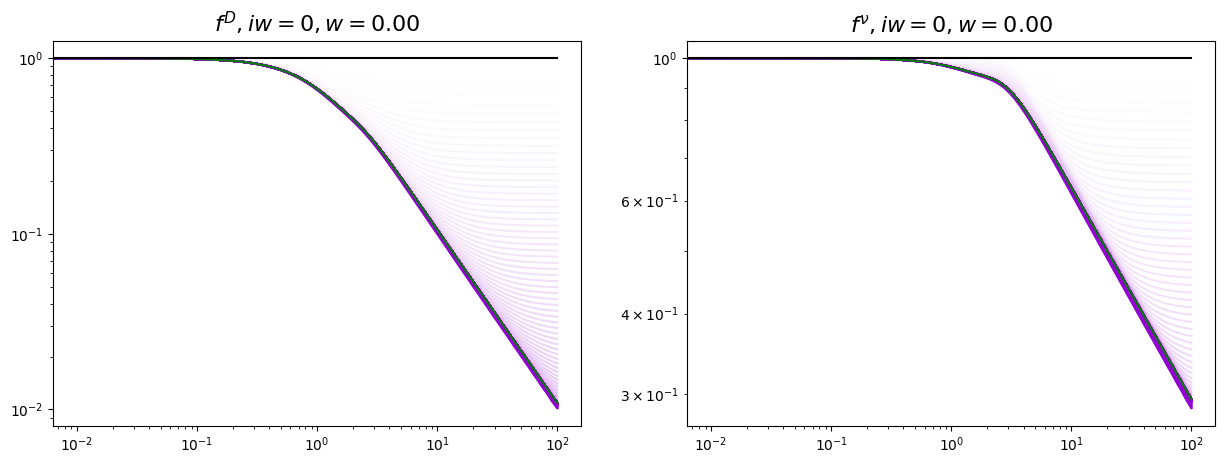

In [18]:
my_plot_NLO.fs_of_p_w0_fixed_alphas(f_D, f_nu, f_in, f_in, flow.p, flow.w, iw0=0, 
                                    s0=0,stepmax=stepmax,step=1,xscale='log', yscale='log')

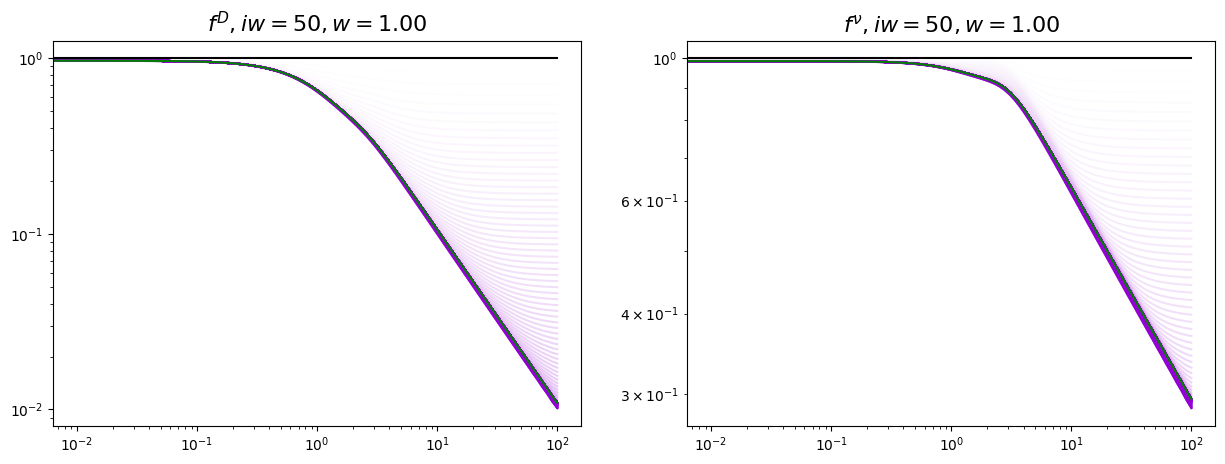

In [19]:
my_plot_NLO.fs_of_p_w0_fixed_alphas(f_D, f_nu, f_in, f_in, flow.p, flow.w, iw0=50, 
                                    s0=0,stepmax=stepmax,step=1,xscale='log', yscale='log')

In [20]:
par = np.loadtxt(
    open(path_save+'/flow_parameters.dat')#.readlines()[:-1] 
)
s = par[:,0]
eta_D_eff = par[:,1]
eta_nu_eff = par[:,2]
g_eff = par[:,3]

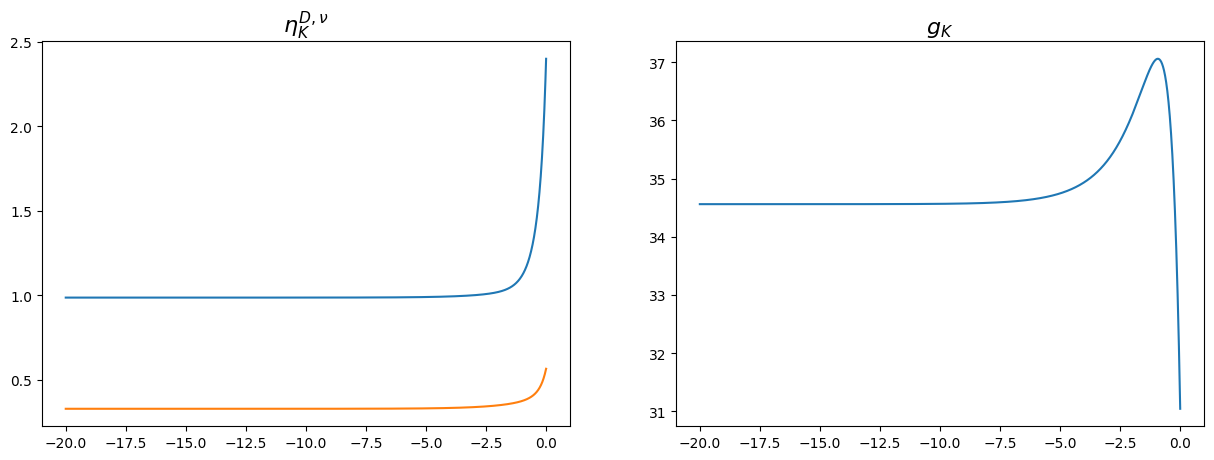

In [21]:
num=2
fig, ax = plt.subplots(1,num, figsize=(7.5*num, 5))

ax[0].set_title(r'$\eta^{D,\nu}_K$', fontsize=16)
ax[0].plot(s, eta_D_eff)
ax[0].plot(s, eta_nu_eff)

ax[1].set_title(r'$g_K$', fontsize=16)
ax[1].plot(s, g_eff)

plt.show()

In [22]:
eta_D_eff[-1], eta_nu_eff[-1], g_eff[-1]

(np.float64(0.986381711171902),
 np.float64(0.32879390235790906),
 np.float64(34.55956451061962))

In [23]:
chi = (2-dim+eta_D_eff[-1]-eta_nu_eff[-1])/2

In [24]:
chi

np.float64(0.32879390440699646)

In [ ]:
# Compare to the version
# === 4_5 ===
# 2D, g_in = 31.:
# 2D_Np10_ds0_01_eps_e-3_Nw10_degq_40      225      s = -10.01	 eta_D = 0.95025	 eta_nu = 0.31677	 g = 33.441
# 2D_Np20_ds0_01_eps_e-3_Nw20_degq_40_pmax_256      s = -10.01	 eta_D = 0.99015	 eta_nu = 0.33008	 g = 34.618
# 2D_Np20_ds0_01_eps_e-3_Nw20_degq_40_pmax_400      s = -10.01	 eta_D = 0.98952	 eta_nu = 0.32987	 g = 34.607  1min 22s

# Kloss2012 NLO (PMS): 0.330 